# 06 — Performance

**Workstream E, tasks E2–E10.** Turns the raw results frame from notebook 05 into the tables and figures
of report section 5 (*Results*). Every headline figure is **net of costs** and is a **median across the
100 experiments**.

| Task | Output |
| --- | --- |
| E2 | **Table 4.1 — Performance conventions** |
| E3, E6 | **Table 4.2 — Net performance by strategy** (gross twin: Table A4.1) |
| E4 | **Table 4.3 — Dispersion** |
| E5 | **Figure 4.1 — Sharpe ratio across 100 experiments** |
| E6 | **Figure 4.2 — Win rate vs equally weighted** |
| E6 | **Table 4.5 — Paired comparison with EW** |
| E7 | **Table 4.4 — Cost impact** |
| E8 | **Figure 4.3 — Growth of $1** (all eight: Figure A4.1) |
| E9 | **Figure 4.4 — Portfolio weights over time** |
| E10 | **Table A.1 — Optimisation failures** |

**The 100 experiments are not 100 independent tests.** The windows overlap in time (Table 3.1 and
Table A3.2) and share assets, so a win rate of 55% across them is a description of these samples, not
a significance test. The report never treats them as independent.

## Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import backtest as bt
from src import config as cfg
from src import data, fmt, viz
from src import performance as pf
from src import strategies as st

viz.use_house_style()
np.random.seed(cfg.SEED)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 140)


#: The strategy the report recommends, for a capital-preservation / moderate-risk investor (report §1, §7).
#: Re-confirmed by the group on the 25-asset universe, from Table 4.5's paired evidence.
#: Changing this redraws Figures 4.3-4.4 and nothing else.
RECOMMENDED = "ERC"

---

## The grid

Rebuilt exactly as in notebook 05, which asserts that the rebuild is bit-identical.

In [2]:
close, volume, extraction_date = data.download_raw()
panel = data.build_panel(close, volume, extraction_date)
prices = panel.prices[cfg.ASSET_ORDER]
experiments = bt.sample_experiments(prices)

grid = pf.run_grid(prices, experiments, st.STRATEGIES, panel.risk_free)
results = pf.results_frame(grid, panel.risk_free)

print(f"Extraction date : {panel.extraction_date.isoformat()}")
print(f"Seed            : {cfg.SEED}")
print(f"Runs            : {len(grid.runs):,} at 1x costs + {len(grid.stressed):,} at 2x")

Extraction date : 2026-10-07
Seed            : 20261001
Runs            : 800 at 1x costs + 800 at 2x


---

## E2 — Table 4.1, performance conventions

The brief asks for the precise conventions, including annualisation, the risk-free rate and the
drawdown denominator. Each formula below is exactly what `src/performance.py` computes. All metrics are
measured on the **evaluation year only** (252 sessions).

**Sterling.** We use the classic form, annualised return over |average annual maximum drawdown| plus
10%. With a one-year evaluation the average is that year's maximum drawdown, so Sterling is Calmar with
a 10-point cushion in the denominator. The cushion matters here: GMV and the risk-based strategies often
have drawdowns of only a few percent, and without it Calmar for those runs can run to double digits.

In [3]:
print("Table 4.1 - Performance conventions. Daily simple returns over each experiment's evaluation year "
      f"(n = {cfg.TRADING_DAYS} sessions); r_f from ^IRX.")
display(pf.conventions_table())

Table 4.1 - Performance conventions. Daily simple returns over each experiment's evaluation year (n = 252 sessions); r_f from ^IRX.


,Formula,Annualisation,Risk-free,Drawdown / denominator
Metric,,,,
Ann. return,(∏(1 + rₜ))^(252/n) − 1,"Geometric; n = 252 sessions, so it is the evaluation year's total return",Not subtracted,—
Ann. volatility,sd(rₜ) × √252,√252 on daily sd (ddof = 1),—,—
Sharpe,"mean(rₜ − r_f,ₜ) × 252 / (sd(rₜ − r_f,ₜ) × √252)","Arithmetic mean ×252, sd ×√252","^IRX daily: yield ÷ 100 ÷ 252, each session",—
Sortino,"mean(rₜ − r_f,ₜ) × 252 / (√mean(min(rₜ − r_f,ₜ, 0)²) × √252)","As Sharpe; downside deviation over all sessions, target r_f",^IRX daily,—
Max drawdown,min over t of Wₜ / maxₛ≤ₜ Wₛ − 1,None — measured over the evaluation year,—,"Wealth path W from 1 at the start of the evaluation year, so a fall from the start counts"
Calmar,Ann. return / |max drawdown|,Annualised return,Not subtracted,|Max drawdown|
Sterling,Ann. return / (|max drawdown| + 10%),Annualised return,Not subtracted,|Average annual max drawdown| + 10% (Jones). With one evaluation year the average is that year's max drawdown. The cushion keeps the rat...
Turnover,"Σ over rebalances of Σᵢ|Δwᵢ|, ÷ evaluation years",Per year; two-way,—,Excludes the opening trade from cash
Gross / net,Net deducts Σᵢ|Δwᵢ| × bpᵢ at each trade,—,—,Definitions §6 bp; 2× in workstream F


---

## E3, E6 — Table 4.2, net performance by strategy

Medians across the 100 experiments, net of costs. *Beats EW* is the share of experiments in which the
strategy's net Sharpe ratio exceeds the equally weighted portfolio's **in the same experiment** (E6).
Each median is taken column by column, so a row is not one experiment's results.

In [4]:
PCT = lambda dp: (lambda v: fmt.percent(v, dp))
headline_rules = {"Ann. return %": PCT(2), "Ann. vol %": PCT(2), "Sharpe": lambda v: fmt.number(v, 2),
                  "Max DD %": PCT(2), "Sterling": lambda v: fmt.number(v, 2), "Turnover %/yr": PCT(1),
                  "Beats EW (Sharpe) %": PCT(0)}

table_4_2 = pf.headline_table(results, "net")
print("Table 4.2 - Net performance by strategy. 100 experiments, median across runs, net of costs "
      f"(definitions §6). Evaluation years {experiments['evaluation_start'].min().date()} to "
      f"{experiments['end'].max().date()}; Yahoo Finance, extracted {panel.extraction_date.isoformat()}.")
display(fmt.style(table_4_2, headline_rules))

Table 4.2 - Net performance by strategy. 100 experiments, median across runs, net of costs (definitions §6). Evaluation years 2013-10-15 to 2026-09-22; Yahoo Finance, extracted 2026-10-07.


metric,Ann. return %,Ann. vol %,Sharpe,Max DD %,Sterling,Turnover %/yr,Beats EW (Sharpe) %
strategy,,,,,,,
EW,14.01,12.50,0.81,-10.14,0.63,21.2,—
GMV,8.88,9.98,0.82,-8.75,0.49,89.4,36
MV,13.31,23.10,0.57,-17.62,0.48,341.0,32
MSR,10.99,16.19,0.72,-12.29,0.51,266.1,35
IV,12.57,11.02,0.82,-9.57,0.60,27.3,45
ERC,11.81,10.26,0.90,-8.75,0.58,31.6,41
MDP,10.99,10.42,0.94,-8.53,0.60,78.4,38
MDC,12.45,11.66,0.86,-9.36,0.61,80.3,53


In [5]:
# Supporting numbers the prose cites, computed rather than typed.
net_sharpe = results[("net", "sharpe")].unstack("strategy")
for s in cfg.STRATEGY_ORDER:
    vol_ratio = table_4_2.loc[s, "Ann. vol %"] / table_4_2.loc["EW", "Ann. vol %"]
    print(f"{s:<4} median vol {vol_ratio:4.2f}x EW's   |   median max DD "
          f"{table_4_2.loc[s, 'Max DD %']:6.2f}% vs EW {table_4_2.loc['EW', 'Max DD %']:6.2f}%")

EW   median vol 1.00x EW's   |   median max DD -10.14% vs EW -10.14%
GMV  median vol 0.80x EW's   |   median max DD  -8.75% vs EW -10.14%
MV   median vol 1.85x EW's   |   median max DD -17.62% vs EW -10.14%
MSR  median vol 1.30x EW's   |   median max DD -12.29% vs EW -10.14%
IV   median vol 0.88x EW's   |   median max DD  -9.57% vs EW -10.14%
ERC  median vol 0.82x EW's   |   median max DD  -8.75% vs EW -10.14%
MDP  median vol 0.83x EW's   |   median max DD  -8.53% vs EW -10.14%
MDC  median vol 0.93x EW's   |   median max DD  -9.36% vs EW -10.14%


**Reading Table 4.2.** Three groups emerge.

- **EW has the highest median return (14.0%) and the best median Sterling ratio.** The universe is
  tilted toward large-cap winners (notebook 01), and an equal-weight portfolio holds them at full
  weight whatever their risk.
- **The risk-based strategies (IV, ERC, MDP, MDC) take less risk for a little less return.** Median
  volatility is 0.82–0.93 times EW's and drawdowns are shallower, at turnover of 27–80% a year. ERC
  and MDP show the highest median Sharpe ratios (0.90 and 0.94, against EW's 0.81). As Table 4.5
  shows, that does not mean they beat EW: the medians come from different experiments.
- **GMV, MV and MSR trail.** GMV gives up the most return (8.9%) to minimise variance. MV and MSR lean
  on noisy trailing means. They turn over 266–341% a year, take 1.3–1.9 times EW's volatility and the
  deepest drawdowns, and beat EW in about a third of experiments. That is the estimation-error
  shortcoming flagged in Table 3.2.

No optimised strategy beats EW in a clear majority of experiments (Figure 4.2). That is consistent with
the literature on naive diversification, and it is a finding worth stating rather than hiding.

---

## E4 — Table 4.3, dispersion

In [6]:
table_4_3 = pf.dispersion_table(results, "net")
print("Table 4.3 - Dispersion across the 100 experiments, net of costs. IQR = 75th minus 25th percentile; "
      "P10 / P90 = 10th / 90th percentiles. Net return is the evaluation year's annualised return.")
display(fmt.style(table_4_3, {c: (lambda v: fmt.number(v, 2)) for c in table_4_3.columns}))

Table 4.3 - Dispersion across the 100 experiments, net of costs. IQR = 75th minus 25th percentile; P10 / P90 = 10th / 90th percentiles. Net return is the evaluation year's annualised return.


Sharpe                    Net return %                     
         Median   IQR    P10   P90       Median    IQR    P10    P90
strategy                                                            
EW         0.81  1.31  -0.07  2.24        14.01  11.14  -1.52  24.74
GMV        0.82  1.14  -0.32  2.00         8.88  12.74  -3.27  18.90
MV         0.57  1.02  -0.34  1.43        13.31  26.19  -8.37  42.38
MSR        0.72  1.03  -0.32  1.65        10.99  16.51  -5.06  31.49
IV         0.82  1.19  -0.09  2.10        12.57  11.07  -1.49  21.62
ERC        0.90  1.17  -0.10  2.13        11.81  11.49  -1.69  20.96
MDP        0.94  1.21  -0.29  2.01        10.99  13.80  -3.10  22.15
MDC        0.86  1.31  -0.17  2.29        12.45  14.41  -2.45  23.66

Dispersion dwarfs the differences between medians. The Sharpe IQR is 1.0–1.3 for every strategy, while
the medians of the six strategies other than MV and MSR sit within 0.13 of each other (0.81–0.94).
Which year and which ten assets an experiment drew matters far more than which strategy ran on them.
Workstream F (period and subset dependence) picks this up.

---

## E5 — Figure 4.1, Sharpe ratio across the 100 experiments

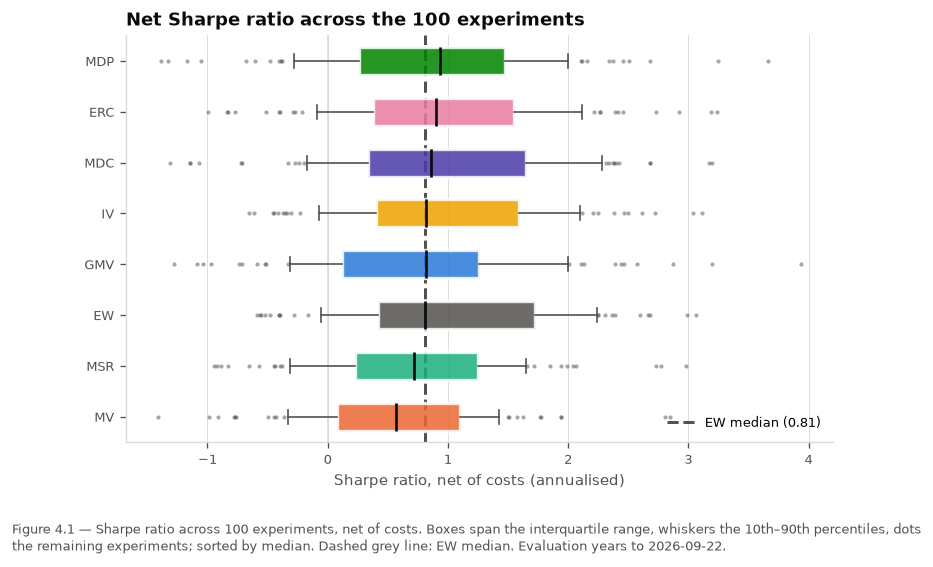

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 4.4))
viz.sharpe_boxplot(net_sharpe, ax=ax)
ax.set_title("Net Sharpe ratio across the 100 experiments")
viz.caption(ax, "Figure 4.1 — Sharpe ratio across 100 experiments, net of costs. Boxes span the interquartile "
                "range, whiskers the 10th–90th percentiles, dots the remaining experiments; sorted by median. "
                f"Dashed grey line: EW median. Evaluation years to {experiments['end'].max().date()}.")
plt.show()

---

## E6 — Figure 4.2, win rate vs equally weighted

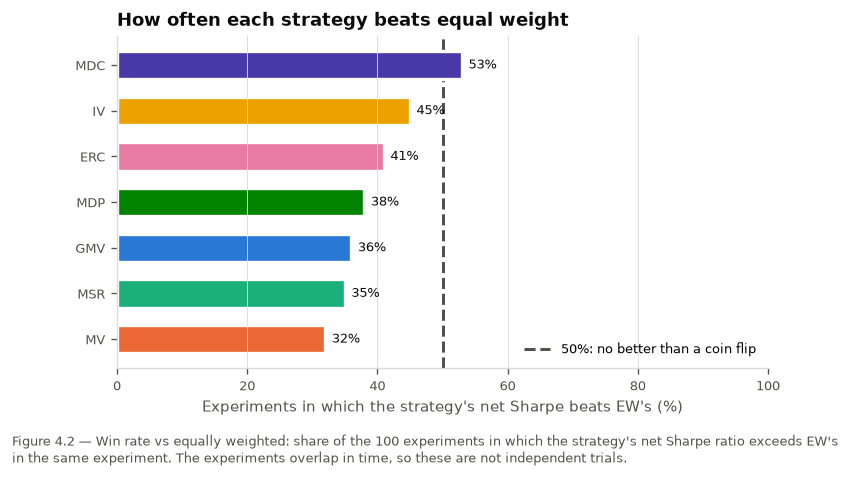

In [8]:
win = pf.win_rate(results)
fig, ax = plt.subplots(figsize=(7.0, 3.6))
viz.win_rate_bars(win, ax=ax)
ax.set_title("How often each strategy beats equal weight")
viz.caption(ax, "Figure 4.2 — Win rate vs equally weighted: share of the 100 experiments in which the strategy's "
                "net Sharpe ratio exceeds EW's in the same experiment. The experiments overlap in time, so "
                "these are not independent trials.")
plt.show()

---

## E6 — Table 4.5, paired comparison with EW

Table 4.2's medians are taken column by column, so a strategy can show a higher median Sharpe than EW
and still lose to it in most experiments: its good results may come in different experiments from
EW's. The brief's own comparison is paired (*the proportion of experiments in which each strategy
outperforms the equally weighted benchmark*). Table 4.5 makes every column paired: each figure is a
median of per-experiment differences from EW, or the share of experiments in which the strategy is
better on that measure.

In [9]:
table_4_5 = pf.paired_table(results)
print("Table 4.5 - Paired comparison with EW. 100 experiments, net of costs. Δ = strategy minus EW in the "
      "same experiment, median across experiments; % = share of experiments in which the strategy is better. "
      "Drawdowns are negative, so a positive Δ max DD is a shallower drawdown.")
display(fmt.style(table_4_5, {
    "Median Δ Sharpe": lambda v: fmt.number(v, 2), "Beats EW (Sharpe) %": PCT(0),
    "Median Δ return pp": lambda v: fmt.number(v, 2), "Median Δ vol pp": lambda v: fmt.number(v, 2),
    "Lower vol %": PCT(0), "Median Δ max DD pp": lambda v: fmt.number(v, 2), "Shallower DD %": PCT(0),
}))

Table 4.5 - Paired comparison with EW. 100 experiments, net of costs. Δ = strategy minus EW in the same experiment, median across experiments; % = share of experiments in which the strategy is better. Drawdowns are negative, so a positive Δ max DD is a shallower drawdown.


,Median Δ Sharpe,Beats EW (Sharpe) %,Median Δ return pp,Median Δ vol pp,Lower vol %,Median Δ max DD pp,Shallower DD %
strategy,,,,,,,
GMV,-0.27,36,-4.49,-2.37,96,0.97,61
MV,-0.33,32,-2.11,9.88,0,-6.90,7
MSR,-0.25,35,-2.73,3.10,18,-1.74,33
IV,-0.01,45,-1.07,-0.92,100,0.53,83
ERC,-0.07,41,-1.93,-1.58,98,0.71,79
MDP,-0.12,38,-2.67,-1.80,90,0.99,68
MDC,0.01,53,-1.04,-0.70,72,0.41,66


In [10]:
# Where the recommended strategy gains and loses against EW: experiments split by EW's own net Sharpe.
ew_sharpe = net_sharpe["EW"]
tercile = pd.qcut(ew_sharpe, 3, labels=["EW's weakest third", "Middle third", "EW's strongest third"])
gap = net_sharpe[RECOMMENDED] - ew_sharpe
by_regime = pd.DataFrame({
    "EW median Sharpe": ew_sharpe.groupby(tercile, observed=True).median(),
    f"Median Δ Sharpe ({RECOMMENDED} − EW)": gap.groupby(tercile, observed=True).median(),
    f"{RECOMMENDED} beats EW %": (gap > 0).groupby(tercile, observed=True).mean() * 100,
})
print(f"{RECOMMENDED} against EW, by how good the year was for EW (terciles of EW's net Sharpe, ~33 experiments each).")
display(fmt.style(by_regime, {by_regime.columns[0]: lambda v: fmt.number(v, 2),
                              by_regime.columns[1]: lambda v: fmt.number(v, 2), by_regime.columns[2]: PCT(0)}))

ERC against EW, by how good the year was for EW (terciles of EW's net Sharpe, ~33 experiments each).


,EW median Sharpe,Median Δ Sharpe (ERC − EW),ERC beats EW %
EW,,,
EW's weakest third,0.28,-0.01,47
Middle third,0.81,0.01,52
EW's strongest third,2.01,-0.21,24


**The paired view changes the reading of Table 4.2.** No strategy has a clearly better Sharpe ratio
than EW in the same experiment. MDC comes closest, beating it in 53% of experiments with a median
difference of +0.01: a tie. IV is level (−0.01), and ERC and MDP give up a little (−0.07 and −0.12).
Their higher *median* Sharpe in Table 4.2 is a cross-sectional effect, not a head-to-head win.

**What the risk-based strategies deliver reliably is lower risk.** IV has lower volatility than EW in
**every** experiment, and ERC in **98%**, with shallower drawdowns in about 80%. The price is 1–2
points of annual return. GMV cuts volatility just as reliably, but at more than twice the return
cost. MV and MSR do the opposite: more risk than EW in most experiments.

**Where ERC gives ground is in EW's best years.** Split the experiments by how good the year was for
EW. In its weakest and middle thirds, ERC and EW are level: about a coin flip, with a median gap of
±0.01. In EW's strongest third (median Sharpe 2.0), ERC trails by 0.21 and wins only a quarter of the
time. In a strong rally, EW's full weight in the most volatile, best-performing stocks pays. ERC
deliberately holds less of them.

**This is the evidence behind the recommendation.** For an investor whose objective is **capital
preservation with moderate risk**, ERC gives the largest, most consistent risk reduction among the
strategies that stay close to EW's risk-adjusted return. It uses the full covariance matrix, so it
reaches the diversifiers (gold, Treasuries) that IV, which ignores correlation, under-weights. The cost
is about two points of return a year, concentrated in strong bull markets. A return-seeking investor
should hold EW, and the report says so.

---

## E7 — Table 4.4, cost impact

*Difference* is the median of the per-experiment differences between net and gross Sharpe, not the
difference of the two medians. *Cost drag* is the median gap between gross and net annual return,
in basis points. It includes the opening trade, which costs every strategy something.

In [11]:
table_4_4 = pf.cost_impact_table(results)
print("Table 4.4 - Cost impact. 100 experiments, medians. Costs per definitions §6 (one-way bp on |Δw|).")
display(fmt.style(table_4_4, {"Gross Sharpe": lambda v: fmt.number(v, 2), "Net Sharpe": lambda v: fmt.number(v, 2),
                              "Difference": lambda v: fmt.number(v, 2), "Cost drag bp/yr": lambda v: fmt.number(v, 1),
                              "Turnover %/yr": PCT(1)}))
print(f"Correlation of cost drag with turnover across strategies: "
      f"{table_4_4['Cost drag bp/yr'].corr(table_4_4['Turnover %/yr']):.2f}")

Table 4.4 - Cost impact. 100 experiments, medians. Costs per definitions §6 (one-way bp on |Δw|).


,Gross Sharpe,Net Sharpe,Difference,Cost drag bp/yr,Turnover %/yr
strategy,,,,,
EW,0.82,0.81,-0.00,4.0,21.2
GMV,0.82,0.82,-0.01,5.6,89.4
MV,0.57,0.57,-0.01,14.0,341.0
MSR,0.72,0.72,-0.01,11.1,266.1
IV,0.82,0.82,-0.00,4.0,27.3
ERC,0.90,0.90,-0.00,4.0,31.6
MDP,0.94,0.94,-0.00,5.4,78.4
MDC,0.86,0.86,-0.00,5.9,80.3


Correlation of cost drag with turnover across strategies: 1.00


In [12]:
# Notebook 03 flagged subsets holding two financials correlated above 0.85. Do they drive turnover?
corr_max = {}
for i, e in experiments.iterrows():
    r = bt.experiment_prices(prices, e).pct_change().iloc[1:]
    window = r.iloc[bt.Schedule().estimation - bt.Schedule().lookback: bt.Schedule().estimation].corr()
    corr_max[i] = window.where(~np.eye(len(window), dtype=bool)).max().max()
has_pair = pd.Series(corr_max) > 0.85
turnover = results[("net", "turnover")].unstack("strategy")[cfg.STRATEGY_ORDER] * 100
print(f"Median turnover %/yr, experiments with a pair above 0.85 (n = {has_pair.sum()}) vs without (n = {(~has_pair).sum()}):")
display(fmt.style(pd.DataFrame({"With a pair > 0.85": turnover[has_pair].median(),
                                "Without": turnover[~has_pair].median()}).T, {s: PCT(0) for s in cfg.STRATEGY_ORDER}))

Median turnover %/yr, experiments with a pair above 0.85 (n = 24) vs without (n = 76):


strategy,EW,GMV,MV,MSR,IV,ERC,MDP,MDC
With a pair > 0.85,22,88,332,245,26,31,81,87
Without,21,90,359,273,27,32,77,80


**Costs do not change the picture at baseline rates.** Every strategy loses under 0.01 of Sharpe to
costs. Every asset here is a liquid US large cap or a large ETF, at 2–3 bp one-way, so costs separate
strategies only by turnover (the correlation between cost drag and turnover across strategies is
1.00). **MV and MSR** pay for their own trading. They turn over several times as much as the risk-based
group and lose 11–14 bp a year, still small next to their gap in gross performance. Workstream F's 2×
run (Table 5.1) tests whether a harsher assumption reorders the ranking.

**The near-collinear bank pairs do not drive turnover.** Notebook 03 flagged the 24 experiments that
hold two financials correlated above 0.85. Their median turnover is no higher than the rest for any
strategy (table above). The long-only constraint stops the optimisers from trading the pair against
each other.

---

## E8 — Figure 4.3, growth of $1 in one experiment

**Which experiment, and why.** The figure needs one experiment, and choosing it by eye would cherry-pick.
The rule, fixed before drawing: take the experiment at the recommended strategy's **median net Sharpe
ratio**, the 50th of the 100 when sorted (the lower median, so that the choice is a single, actual
experiment). That is the recommended strategy's most typical year.

Representative experiment for ERC: #22, assets ORCL, AMZN, PFE, UNH, BAC, AXP, PEP, CL, GLD, SLV, evaluation 2019-10-01 to 2020-09-29.
ERC net Sharpe here 0.89; median across experiments 0.90 (between the 50th and 51st).


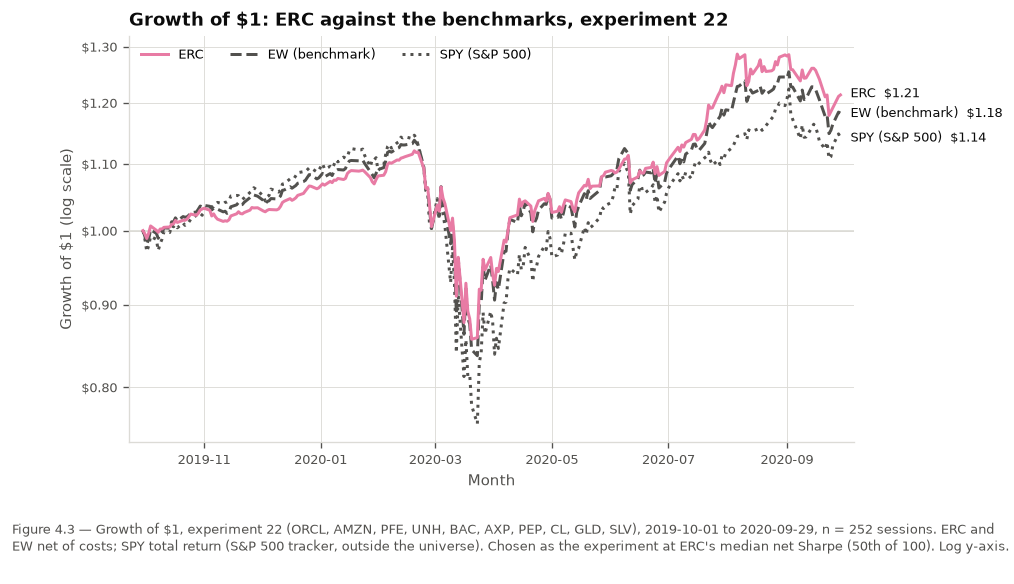

In [13]:
rep = pf.representative_experiment(results, RECOMMENDED)
e = experiments.loc[rep]
run = grid.runs[(rep, RECOMMENDED)]
ew_run = grid.runs[(rep, "EW")]
spy = panel.prices[cfg.PERFORMANCE_BENCHMARK].loc[e["estimation_end"]: e["end"]]
spy = spy / spy.iloc[0]

print(f"Representative experiment for {RECOMMENDED}: #{rep}, assets {', '.join(e['assets'])}, "
      f"evaluation {e['evaluation_start'].date()} to {e['end'].date()}.")
print(f"{RECOMMENDED} net Sharpe here {results.loc[(rep, RECOMMENDED), ('net', 'sharpe')]:.2f}; "
      f"median across experiments {net_sharpe[RECOMMENDED].median():.2f} (between the 50th and 51st).")

fig, ax = plt.subplots(figsize=(7.8, 4.4))
viz.wealth_paths(
    {RECOMMENDED: run.wealth()},
    {"EW (benchmark)": (ew_run.wealth(), cfg.BENCHMARK_STYLE),
     "SPY (S&P 500)": (spy, {**cfg.BENCHMARK_STYLE, "linestyle": ":"})},
    ax=ax,
)
ax.set_title(f"Growth of $1: {RECOMMENDED} against the benchmarks, experiment {rep}")
viz.caption(ax, f"Figure 4.3 — Growth of $1, experiment {rep} ({', '.join(e['assets'])}), "
                f"{e['evaluation_start'].date()} to {e['end'].date()}, n = {len(run.net)} sessions. "
                f"{RECOMMENDED} and EW net of costs; SPY total return (S&P 500 tracker, outside the universe). "
                f"Chosen as the experiment at {RECOMMENDED}'s median net Sharpe (50th of 100). Log y-axis.")
plt.show()

**Appendix — Figure A4.1, all eight strategies in the same experiment.** Small multiples, each against
EW, so that no panel carries more than two lines. EW is drawn on top.

This experiment's evaluation year contains the COVID crash, and MV shows the concentration risk of
Table 3.2 at its starkest. At the December 2019 rebalance it put **100% into one bank**, held that
through March 2020, and then switched entirely to gold. It ends the year at $0.80, while every other
strategy ends above $1.15.

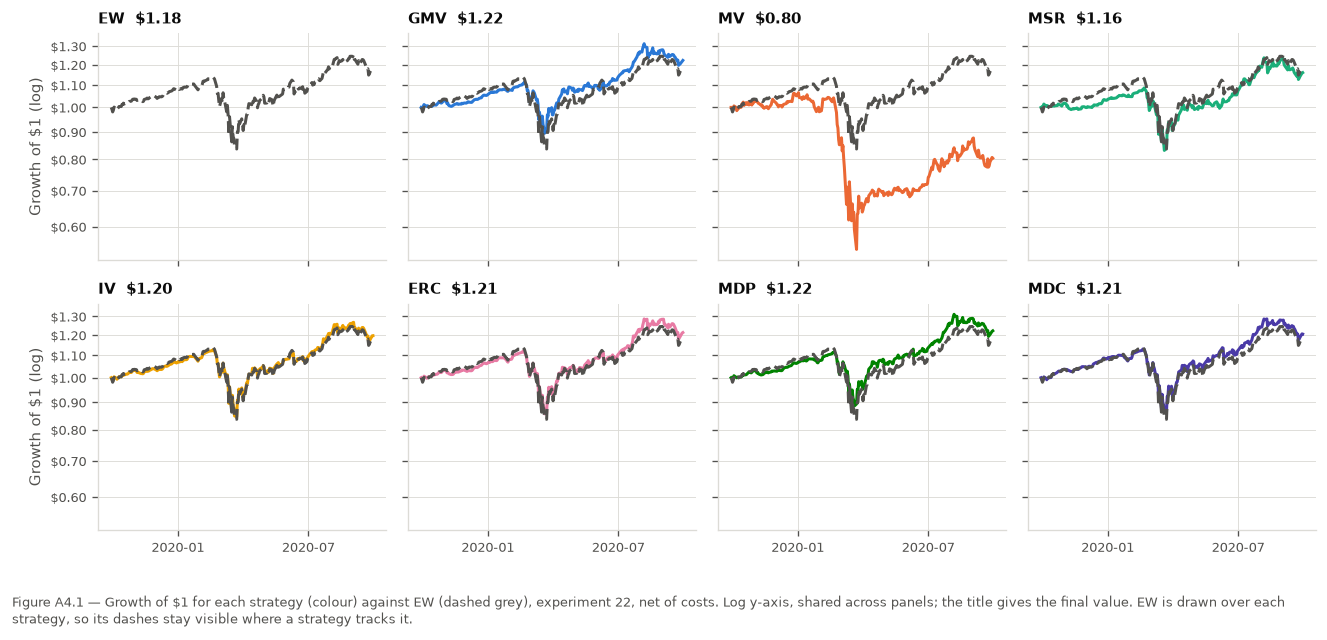

MDC vs EW in experiment 22: largest wealth gap 4.90%, largest weight gap 27.7 pp.


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(11, 4.8), sharex=True, sharey=True)
ew_wealth = ew_run.wealth()
for ax, s in zip(axes.flat, cfg.STRATEGY_ORDER):
    if s != "EW":
        w = grid.runs[(rep, s)].wealth()
        ax.plot(w.index, w, color=viz.strategy_color(s), label=s, zorder=2)
    # EW on top, so its dashes stay visible where a strategy tracks it closely (MDC).
    ax.plot(ew_wealth.index, ew_wealth, **cfg.BENCHMARK_STYLE, label="EW", zorder=3)
    ax.set_title(f"{s}  ${grid.runs[(rep, s)].wealth().iloc[-1]:.2f}", fontsize=9)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:.2f}"))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
lo, hi = axes[0, 0].get_ylim()
axes[0, 0].yaxis.set_major_locator(plt.FixedLocator(np.arange(np.ceil(lo * 10) / 10, hi, 0.1)))
for ax in axes[:, 0]:
    ax.set_ylabel("Growth of $1 (log)")
fig.tight_layout()
viz.caption(axes[1, 0], f"Figure A4.1 — Growth of $1 for each strategy (colour) against EW (dashed grey), "
                        f"experiment {rep}, net of costs. Log y-axis, shared across panels; the title gives the "
                        "final value. EW is drawn over each strategy, so its dashes stay visible where a strategy tracks it.")
plt.show()

mdc = grid.runs[(rep, "MDC")]
print(f"MDC vs EW in experiment {rep}: largest wealth gap "
      f"{(mdc.wealth() / ew_wealth - 1).abs().max() * 100:.2f}%, largest weight gap "
      f"{(mdc.weights - ew_run.weights).abs().max().max() * 100:.1f} pp.")

---

## E9 — Figure 4.4, weights over time

The recommended strategy's daily weights in the same experiment. Between the dotted rebalance lines,
the weights drift with returns, and they reset at each quarterly trade.

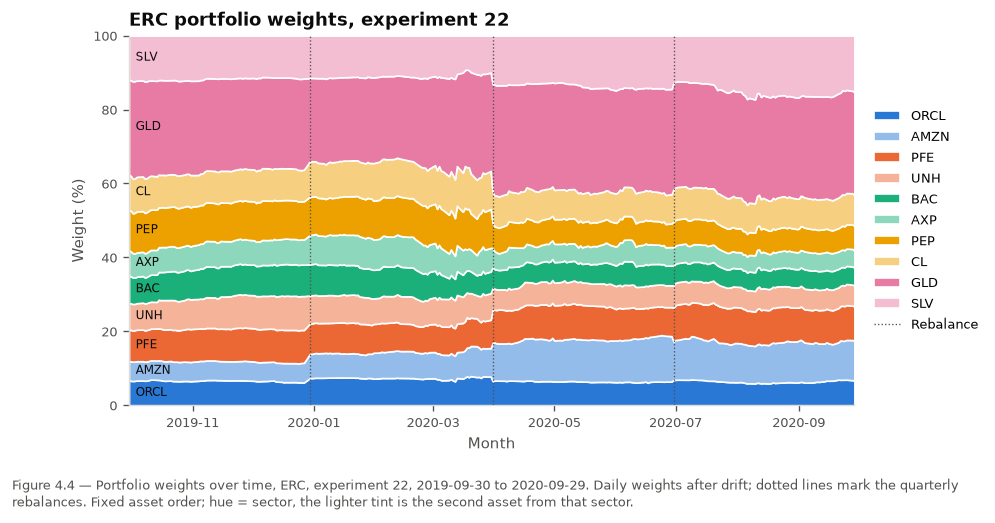

Mean weight %: {'ORCL': 6.7, 'AMZN': 8.6, 'PFE': 8.7, 'UNH': 6.8, 'BAC': 6.5, 'AXP': 6.0, 'PEP': 8.5, 'CL': 8.8, 'GLD': 26.4, 'SLV': 12.9}


In [15]:
fig, ax = plt.subplots(figsize=(7.8, 4.0))
viz.weights_area(run.weights, list(run.trades["execution"].iloc[1:]), ax=ax)
ax.set_title(f"{RECOMMENDED} portfolio weights, experiment {rep}")
viz.caption(ax, f"Figure 4.4 — Portfolio weights over time, {RECOMMENDED}, experiment {rep}, "
                f"{run.weights.index[0].date()} to {run.weights.index[-1].date()}. Daily weights after drift; "
                "dotted lines mark the quarterly rebalances. Fixed asset order; hue = sector, the lighter tint is the "
                "second asset from that sector.")
plt.show()

mean_w = run.weights.mean().reindex([a for a in cfg.ASSET_ORDER if a in run.weights.columns])
print("Mean weight %:", (mean_w * 100).round(1).to_dict())

The weights show ERC's best-known trait: **the lowest-volatility, least-correlated assets take the
largest weights**, because they need the most capital to contribute an equal share of risk. Here gold
averages 26% and silver 13%, so the two precious-metal ETFs hold about two-fifths of the capital,
against 20% under EW. The eight equities share the rest at 6–9% each. Risk is balanced, but capital
leans on the defensive block, which is why ERC lags in strong equity rallies (Table 4.5). Workstream F's
concentration table (Table 5.3) measures this across all 100 experiments.

The weights also show what the quarterly schedule does in a crisis. Through March 2020, ERC held the
allocation it set at the end of December, so it de-risked only at the 31 March rebalance, after the
fall. Notebook 02 measured the volatility half-life at about a month, shorter than the rebalancing
interval.

---

## Appendix — Table A4.1, gross performance

Table 4.2 before costs, for comparison.

In [16]:
table_a4_1 = pf.headline_table(results, "gross")
print("Table A4.1 - Gross performance by strategy. As Table 4.2, before transaction costs.")
display(fmt.style(table_a4_1, headline_rules))

Table A4.1 - Gross performance by strategy. As Table 4.2, before transaction costs.


metric,Ann. return %,Ann. vol %,Sharpe,Max DD %,Sterling,Turnover %/yr,Beats EW (Sharpe) %
strategy,,,,,,,
EW,14.05,12.50,0.82,-10.14,0.64,21.2,—
GMV,8.93,9.98,0.82,-8.74,0.49,89.4,36
MV,13.46,23.10,0.57,-17.59,0.48,341.0,32
MSR,11.09,16.19,0.72,-12.26,0.52,266.1,35
IV,12.61,11.02,0.82,-9.57,0.60,27.3,45
ERC,11.85,10.26,0.90,-8.74,0.59,31.6,42
MDP,11.04,10.42,0.94,-8.52,0.60,78.4,39
MDC,12.51,11.66,0.86,-9.36,0.61,80.3,53


---

## E10 — Table A.1, optimisation failures

From the C6 log. The table is shown even when it is short. Every listed rebalance kept its run, which
held its drifted weights.

In [17]:
failures = bt.failure_log(list(grid.runs.values()))
n_rebalances = len(grid.runs) * len(bt.Schedule().execution_positions())
print(f"Table A.1 - Optimisation failures. {len(failures)} of {n_rebalances:,} rebalances "
      f"({len(grid.runs)} runs x 4); no run dropped.")
if failures.empty:
    print("No optimisation failed.")
else:
    display(failures.assign(date=failures["date"].dt.date)
            .rename(columns={"experiment": "Experiment", "date": "Formation date", "strategy": "Strategy",
                             "error": "Error", "fallback": "Fallback used"}))

Table A.1 - Optimisation failures. 0 of 3,200 rebalances (800 runs x 4); no run dropped.
No optimisation failed.


---

## Done-when checks

In [18]:
checks = []
checks.append(("Table 4.2 is net of costs and covers the eight strategies in fixed order",
               list(table_4_2.index) == cfg.STRATEGY_ORDER and table_4_2.notna().drop(columns="Beats EW (Sharpe) %").all().all()))

again = pf.headline_table(pf.results_frame(
    pf.run_grid(prices, bt.sample_experiments(prices), st.STRATEGIES, panel.risk_free), panel.risk_free), "net")
checks.append(("Every number in Table 4.2 reproduces under the fixed seed", again.equals(table_4_2)))

checks.append(("Net and gross differ, and net is never above gross",
               (table_4_2["Ann. return %"] <= table_a4_1["Ann. return %"] + 1e-12).all()))
checks.append(("Win rate reported for every strategy but EW", win.drop("EW").notna().all()))
checks.append(("Table 4.5 pairs every strategy with EW, and its win rate matches Figure 4.2",
               list(table_4_5.index) == cfg.STRATEGY_ORDER[1:]
               and np.allclose(table_4_5["Beats EW (Sharpe) %"], win.drop("EW") * 100)))
checks.append(("Table A.1 built from the failure log (no run dropped)",
               len(results) == cfg.N_EXPERIMENTS * len(cfg.STRATEGY_ORDER)))

for label, ok in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {label}")
assert all(ok for _, ok in checks), "workstream E exit criteria not met"

[PASS] Table 4.2 is net of costs and covers the eight strategies in fixed order
[PASS] Every number in Table 4.2 reproduces under the fixed seed
[PASS] Net and gross differ, and net is never above gross
[PASS] Win rate reported for every strategy but EW
[PASS] Table 4.5 pairs every strategy with EW, and its win rate matches Figure 4.2
[PASS] Table A.1 built from the failure log (no run dropped)


---

## Handoff

| Output | Report |
| --- | --- |
| Table 4.1 | Section 4, *Methods and assumptions* |
| Tables 4.2–4.4, Figures 4.1–4.4 | Section 5, *Results* |
| Tables A4.1, A.1; Figure A4.1 | Appendix |
| `RECOMMENDED = "ERC"` | Sections 1 and 7. Stated objective: capital preservation / moderate risk. Evidence: Table 4.5. Lower volatility than EW in 98% of experiments and a shallower drawdown in 79%, for about 2 pp of return; level with EW on Sharpe except in EW's strongest years. Reconsider for a return-seeking investor (hold EW) |

Workstream F (notebook 07) reuses `results`: `net_2x` for Table 5.1, `experiments` for the period and
subset splits, and `grid.runs` for concentration.